## Setup

**Test date: 1.5.2026**

**CPU**: AMD Ryzen 9 7950X 16-Core Processor

**RAM**: 128GB DDR5 G-Skill Trident Z5

**GPU**: NVIDIA RTX 4090

Running on **Ollama v0.21.0** and **Open WebUI v0.9.2** as the interface.

**Qwen2.5-coder:32b** was tasked with generating a **couch** using the **SPOMSO** package. The model was provided with the [spomso_sdf_guide](./guides/spomso_sdf_guide.md) file and the following prompt:

*Read through the attached .md file. It contains a guide how to use the Python package SPOMSO. I want you to design a couch using this Python package. As the output I want some code that I would run and it would output the point cloud of the object and some figures. Make sure that the resulting plots show true proportions of the object. Everything else I leave up to you. Good luck and if you have any questions feel free to ask.*

## Response:

Sure, let's design a simple couch using the SPOMSO package. The couch will consist of a seat, backrests, and four legs. We'll use the guide provided to create the geometry, apply transformations, combine shapes, and visualize the results.

Here is the code that you can run to generate the point cloud and some figures:

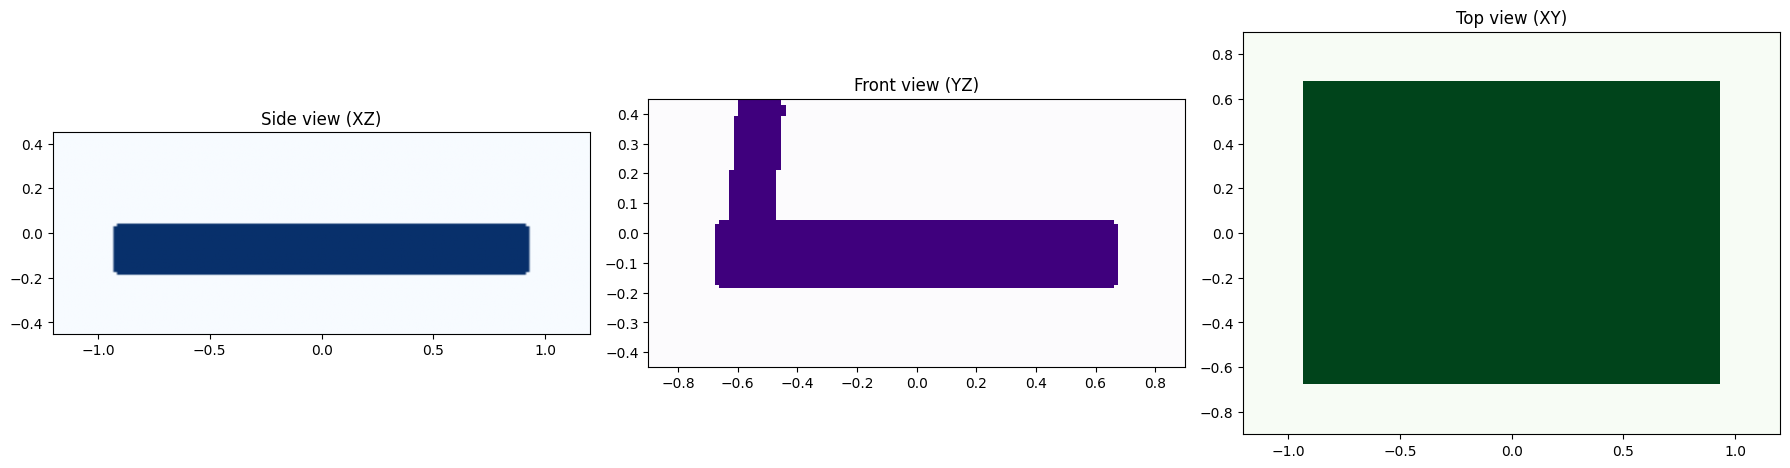

Point cloud saved: 121,145 points


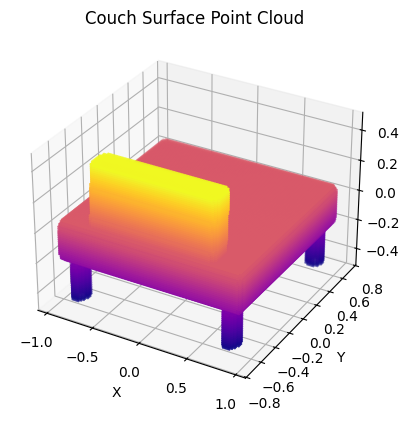

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.cores.post_processing import hard_binarization
from spomso.cores.geom_3d import Box, Cylinder
from spomso.cores.combine import CombineGeometry

# Define the grid
CO_SIZE = (2.4, 1.8, 0.9)  # Physical size of the grid
CO_RESOLUTION = (150, 112, 75)  # Resolution of the grid
coor, co_res_new = generate_grid(CO_SIZE, CO_RESOLUTION)

# Create the seat
seat = Box(1.8, 1.3, 0.15)
seat.rounding(0.04)
seat.move((0.0, 0.0, -0.07))  # top surface at z = -0.02

# Create the backrests
backrest_left = Box(0.6, 0.08, 0.5)
backrest_left.rounding(0.04)
backrest_left.move((-0.3, -0.55, 0.175))
backrest_left.rotate(np.deg2rad(-5), (1, 0, 0))   # tilt backrests slightly

backrest_right = Box(0.6, 0.08, 0.5)
backrest_right.rounding(0.04)
backrest_right.move((0.3, -0.55, 0.175))
backrest_right.rotate(np.deg2rad(-5), (1, 0, 0))

# Create the legs
leg_positions = [(-0.8, -0.6, -0.4), (-0.8, 0.6, -0.4),
                 (0.8, -0.6, -0.4), (0.8, 0.6, -0.4)]
legs = []
for pos in leg_positions:
    leg = Cylinder(0.05, 0.3)
    leg.rounding(0.01)
    leg.move(pos)
    legs.append(leg)

# Combine all parts of the couch
couch = CombineGeometry("UNION").combine(
    seat, backrest_left, backrest_right, *legs
)

sdf = couch.create(coor)

# Generate binary field and cross-sections
binary_3d = smarter_reshape(hard_binarization(sdf, 0), CO_RESOLUTION)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Side view (XZ)
axes[0].imshow(binary_3d[:, CO_RESOLUTION[1]//2, :].T,
               cmap="Blues", origin="lower",
               extent=(-CO_SIZE[0]/2, CO_SIZE[0]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2))
axes[0].set_title("Side view (XZ)")

# Front view (YZ)
axes[1].imshow(binary_3d[CO_RESOLUTION[0]//2, :, :].T,
               cmap="Purples", origin="lower",
               extent=(-CO_SIZE[1]/2, CO_SIZE[1]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2))
axes[1].set_title("Front view (YZ)")

# Top view (XY)
axes[2].imshow(binary_3d[:, :, CO_RESOLUTION[2]//2].T,
               cmap="Greens", origin="lower",
               extent=(-CO_SIZE[0]/2, CO_SIZE[0]/2, -CO_SIZE[1]/2, CO_SIZE[1]/2))
axes[2].set_title("Top view (XY)")

plt.tight_layout()
plt.show()

# Generate surface point cloud
dx = CO_SIZE[0] / CO_RESOLUTION[0]
surface_pts = coor[:, np.abs(sdf) < dx * 1.5].T
np.save("couch_surface.npy", surface_pts)
print(f"Point cloud saved: {surface_pts.shape[0]:,} points")

# Plot the point cloud in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(surface_pts[:, 0], surface_pts[:, 1], surface_pts[:, 2],
           c=surface_pts[:, 2], cmap="plasma", s=0.5)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.title("Couch Surface Point Cloud")
plt.show()

This code will create a simple couch and output cross-sections in the XZ, YZ, and XY planes as well as a 3D scatter plot of the surface point cloud. The dimensions and proportions of the couch are chosen arbitrarily to demonstrate how the package can be used. You can adjust the dimensions and other parameters to better fit your needs.

**End response**

**Approximate time:** 3m 40s

## Validation

The entire **object** can be visualized with the code below:

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Volume(
    x=coor[0],
    y=coor[1],
    z=coor[2],
    value=hard_binarization(sdf, 0),
    isomin=0.9,
    isomax=1,
    opacity=1,
    surface_count=2,
))
fig.show()